
=== Toy Data (with outlier) ===
Count: 5
Mean: 29.2000
Median: 12.0000
Mode (first): 10.0000
Std Dev: 39.5942
Variance: 1567.7000
Min: 10.0000
Q1 (25%): 11.0000
Q3 (75%): 13.0000
IQR: 2.0000
Max: 100.0000
Skewness: 2.2316
Excess Kurtosis: 4.9841

Interpretation:
- Mean is pulled toward the outlier (100).
- Median stays near the typical cluster (10–13).


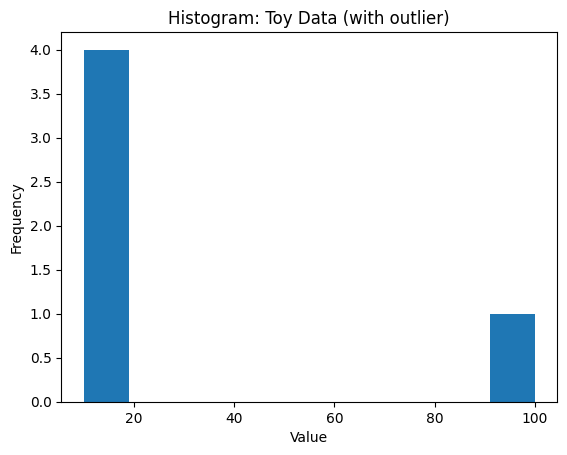

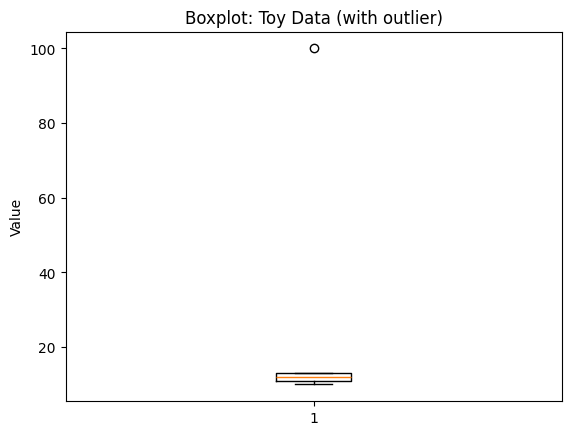


=== B1: Gaussian Data (loc=50, scale=5, n=1000) ===
Count: 1000
Mean: 49.7737
Median: 49.7099
Mode (first): 34.7693
Std Dev: 4.9376
Variance: 24.3802
Min: 34.7693
Q1 (25%): 46.5079
Q3 (75%): 53.0348
IQR: 6.5269
Max: 63.7968
Skewness: 0.0339
Excess Kurtosis: -0.0410


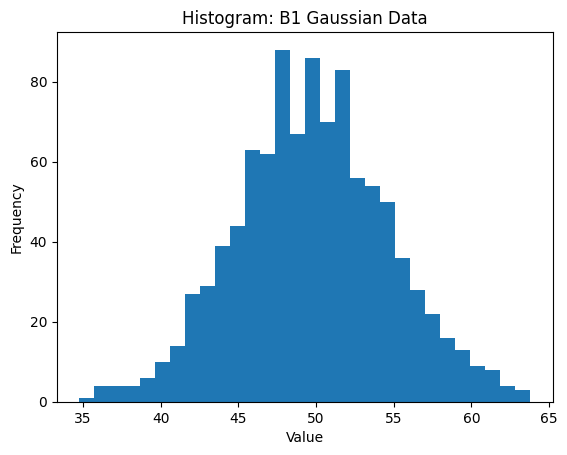

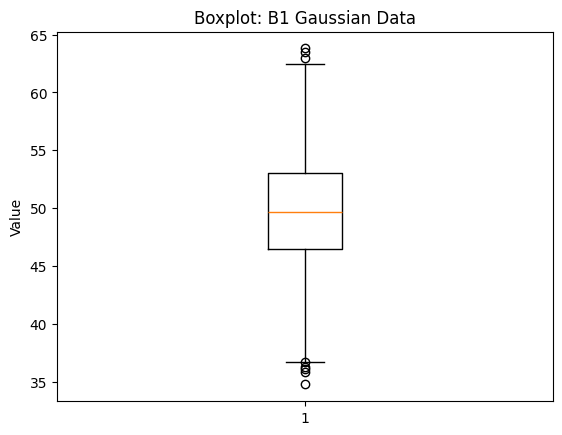


=== B2: Gaussian + Outliers [200, 250, 300] ===
Count: 1003
Mean: 50.3726
Median: 49.7193
Mode (first): 34.7693
Std Dev: 12.2053
Variance: 148.9699
Min: 34.7693
Q1 (25%): 46.5228
Q3 (75%): 53.0558
IQR: 6.5330
Max: 300.0000
Skewness: 14.7510
Excess Kurtosis: 267.2702


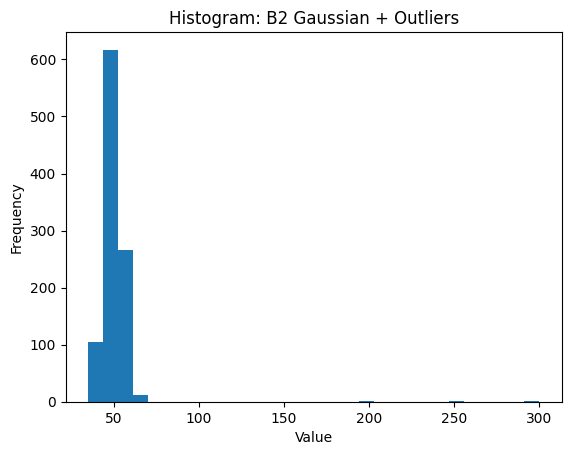

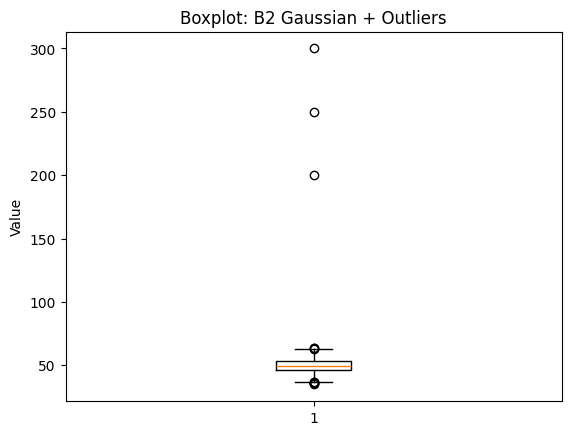


=== B3: Error Comparison on (Gaussian + Outliers) ===
Candidate Mean:   50.3726
Candidate Median: 49.7193
Total Absolute Error if using Mean:   4561.6881
Total Absolute Error if using Median: 4523.6109
Total Squared Error if using Mean:    149267.8194
Total Squared Error if using Median:  149695.8532

=== B4: What this demonstrates ===
- The MEDIAN minimizes total ABSOLUTE error (more robust to outliers).
- The MEAN minimizes total SQUARED error (outliers matter a lot).

=== Skew/Kurt Example 1: Normal(0,1) (symmetric) ===
Count: 5000
Mean: 0.0243
Median: 0.0313
Mode (first): -3.2530
Std Dev: 1.0026
Variance: 1.0053
Min: -3.2530
Q1 (25%): -0.6510
Q3 (75%): 0.6860
IQR: 1.3370
Max: 3.9586
Skewness: -0.0055
Excess Kurtosis: -0.0234


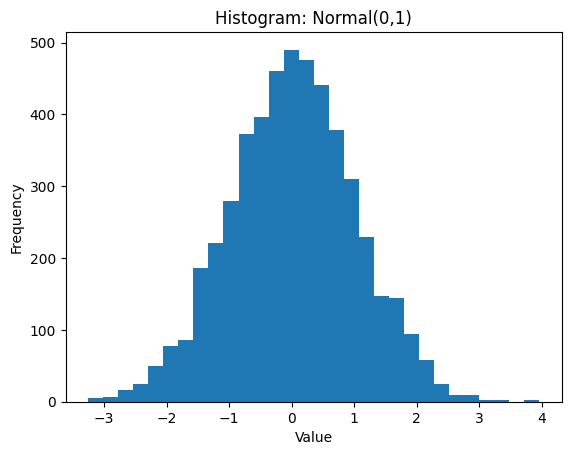

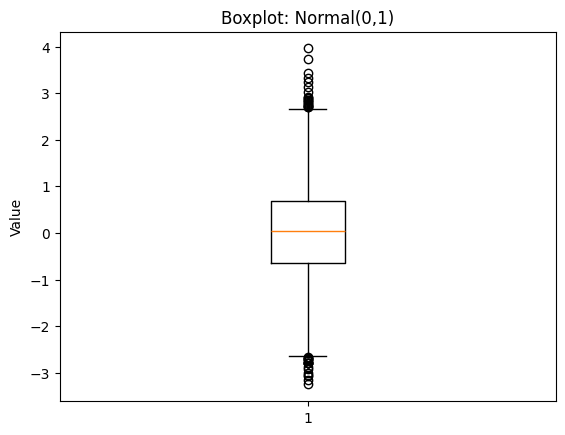


=== Skew/Kurt Example 2: Exponential(scale=1) (positive skew) ===
Count: 5000
Mean: 0.9776
Median: 0.6815
Mode (first): 0.0000
Std Dev: 0.9762
Variance: 0.9530
Min: 0.0000
Q1 (25%): 0.2848
Q3 (75%): 1.3542
IQR: 1.0694
Max: 8.3094
Skewness: 1.9999
Excess Kurtosis: 5.7624


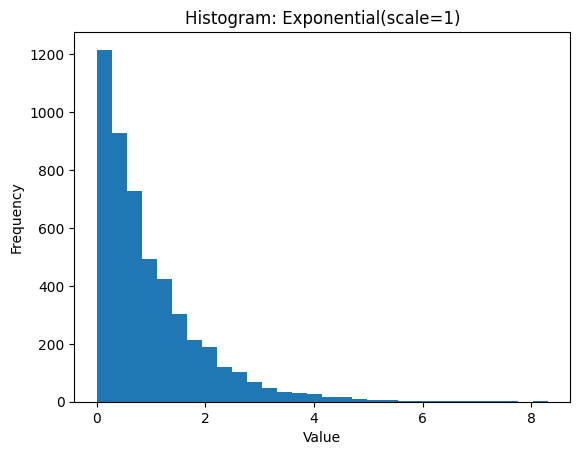

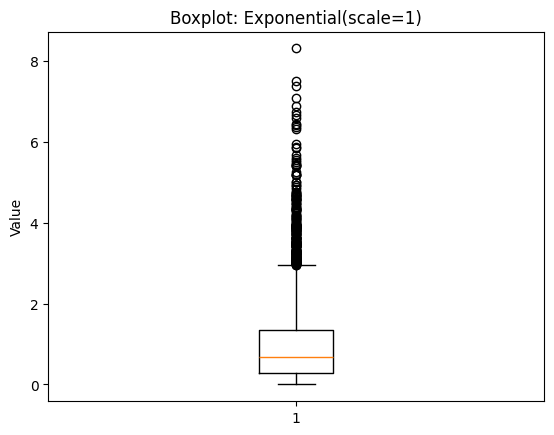


=== Skew/Kurt Example 3: Student-t(df=3) (heavy tails) ===
Count: 5000
Mean: 0.0167
Median: 0.0020
Mode (first): -20.3825
Std Dev: 1.7183
Variance: 2.9525
Min: -20.3825
Q1 (25%): -0.7744
Q3 (75%): 0.7485
IQR: 1.5229
Max: 27.7957
Skewness: 1.5671
Excess Kurtosis: 31.1912


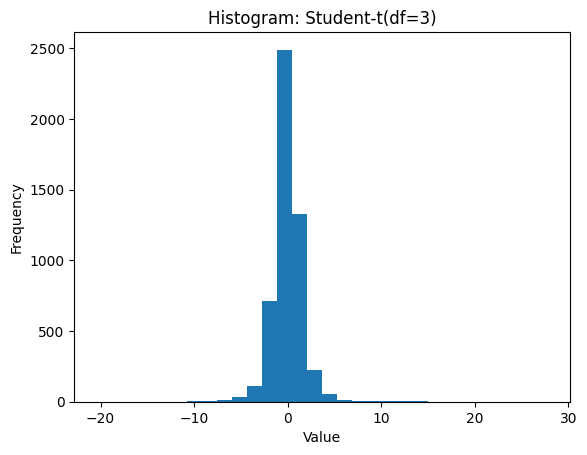

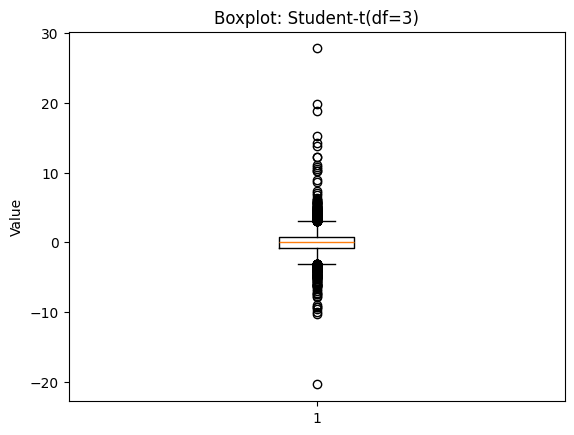


--- Shape Diagnosis: Normal(0,1) ---
Skewness: -0.006 (0 means symmetric; + right tail; - left tail)
Excess Kurtosis: -0.023 (0 ~ normal tails; >0 heavier tails; <0 lighter tails)
Symmetry: roughly symmetric (mean often reasonable).
Tails: roughly normal-ish tail behavior.

--- Shape Diagnosis: Exponential(scale=1) ---
Skewness: 2.000 (0 means symmetric; + right tail; - left tail)
Excess Kurtosis: 5.762 (0 ~ normal tails; >0 heavier tails; <0 lighter tails)
Symmetry: positive skew (median often more representative than mean).
Tails: heavy-tailed (outliers more common; mean/MSE can be fragile).

--- Shape Diagnosis: Student-t(df=3) ---
Skewness: 1.567 (0 means symmetric; + right tail; - left tail)
Excess Kurtosis: 31.191 (0 ~ normal tails; >0 heavier tails; <0 lighter tails)
Symmetry: positive skew (median often more representative than mean).
Tails: heavy-tailed (outliers more common; mean/MSE can be fragile).

Done. Run this as a single script or paste into a Jupyter notebook cell-by

In [2]:
# ============================================================
# Python for Data Analysis: Descriptive Statistics
# Covered topics:
# 1) Mean vs Median (robustness + intuition)
# 2) Why Mean is optimal for squared error; Median for absolute error
# 3) Simulations: Gaussian data vs Outliers
# 4) Skewness & Kurtosis (shape diagnostics)
# 5) Visual diagnostics: histogram + boxplot
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Helper: Pretty printing
# -------------------------------
def summarize_series(s: pd.Series, name: str = "Series"):
    """Print key descriptive stats with skewness and kurtosis."""
    print(f"\n=== {name} ===")
    print(f"Count: {s.count()}")
    print(f"Mean: {s.mean():.4f}")
    print(f"Median: {s.median():.4f}")
    # mode() can return multiple values; show first if exists
    mode_vals = s.mode(dropna=True)
    if len(mode_vals) > 0:
        print(f"Mode (first): {mode_vals.iloc[0]:.4f}")
    else:
        print("Mode: (none)")
    print(f"Std Dev: {s.std(ddof=1):.4f}")   # sample std dev
    print(f"Variance: {s.var(ddof=1):.4f}") # sample variance
    print(f"Min: {s.min():.4f}")
    print(f"Q1 (25%): {s.quantile(0.25):.4f}")
    print(f"Q3 (75%): {s.quantile(0.75):.4f}")
    print(f"IQR: {(s.quantile(0.75) - s.quantile(0.25)):.4f}")
    print(f"Max: {s.max():.4f}")
    print(f"Skewness: {s.skew():.4f}")
    # pandas kurtosis is "excess kurtosis" by default (normal ≈ 0)
    print(f"Excess Kurtosis: {s.kurtosis():.4f}")

def plot_hist_box(s: pd.Series, title: str, bins: int = 30):
    """Plot histogram and boxplot (separate figures to keep it simple)."""
    plt.figure()
    plt.hist(s.dropna().values, bins=bins)
    plt.title(f"Histogram: {title}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure()
    plt.boxplot(s.dropna().values, vert=True)
    plt.title(f"Boxplot: {title}")
    plt.ylabel("Value")
    plt.show()

# ============================================================
# PART 1: Mean vs Median with Outliers (Intuition)
# ============================================================

# Simple toy example
toy = pd.Series([10, 11, 12, 13, 100], name="toy")
summarize_series(toy, "Toy Data (with outlier)")

# Show how mean gets pulled by outlier while median stays "typical"
print("\nInterpretation:")
print("- Mean is pulled toward the outlier (100).")
print("- Median stays near the typical cluster (10–13).")

plot_hist_box(toy, "Toy Data (with outlier)", bins=10)

# ============================================================
# PART 2: Simulation B1, B2, B3, B4 (Gaussian -> add outliers -> compare errors)
# ============================================================

np.random.seed(0)

# B1: Gaussian-like data
data_gaussian = pd.Series(np.random.normal(loc=50, scale=5, size=1000), name="gaussian")
summarize_series(data_gaussian, "B1: Gaussian Data (loc=50, scale=5, n=1000)")
plot_hist_box(data_gaussian, "B1 Gaussian Data")

# B2: Add outliers
data_with_outliers = pd.Series(
    np.append(data_gaussian.values, [200, 250, 300]),
    name="gaussian_plus_outliers"
)
summarize_series(data_with_outliers, "B2: Gaussian + Outliers [200, 250, 300]")
plot_hist_box(data_with_outliers, "B2 Gaussian + Outliers")

# B3: Compare absolute error vs squared error for candidate mean and candidate median
candidate_mean = data_with_outliers.mean()
candidate_median = data_with_outliers.median()

abs_error_mean = np.sum(np.abs(data_with_outliers.values - candidate_mean))
abs_error_median = np.sum(np.abs(data_with_outliers.values - candidate_median))

sq_error_mean = np.sum((data_with_outliers.values - candidate_mean) ** 2)
sq_error_median = np.sum((data_with_outliers.values - candidate_median) ** 2)

print("\n=== B3: Error Comparison on (Gaussian + Outliers) ===")
print(f"Candidate Mean:   {candidate_mean:.4f}")
print(f"Candidate Median: {candidate_median:.4f}")
print(f"Total Absolute Error if using Mean:   {abs_error_mean:.4f}")
print(f"Total Absolute Error if using Median: {abs_error_median:.4f}")
print(f"Total Squared Error if using Mean:    {sq_error_mean:.4f}")
print(f"Total Squared Error if using Median:  {sq_error_median:.4f}")

# B4: What we proved
print("\n=== B4: What this demonstrates ===")
print("- The MEDIAN minimizes total ABSOLUTE error (more robust to outliers).")
print("- The MEAN minimizes total SQUARED error (outliers matter a lot).")

# ============================================================
# PART 3: Skewness & Kurtosis (Shape Diagnostics)
# ============================================================

np.random.seed(1)

# A "nice" symmetric dataset (Gaussian)
normal_data = pd.Series(np.random.normal(loc=0, scale=1, size=5000), name="normal_0_1")
summarize_series(normal_data, "Skew/Kurt Example 1: Normal(0,1) (symmetric)")
plot_hist_box(normal_data, "Normal(0,1)")

# A positively skewed dataset (Exponential) - long right tail
skewed_data = pd.Series(np.random.exponential(scale=1.0, size=5000), name="exponential")
summarize_series(skewed_data, "Skew/Kurt Example 2: Exponential(scale=1) (positive skew)")
plot_hist_box(skewed_data, "Exponential(scale=1)")

# A heavy-tailed dataset (Student's t with small df) - more extreme values
# (Heavier tails than normal; kurtosis tends to be higher)
heavy_tail_data = pd.Series(np.random.standard_t(df=3, size=5000), name="t_df3")
summarize_series(heavy_tail_data, "Skew/Kurt Example 3: Student-t(df=3) (heavy tails)")
plot_hist_box(heavy_tail_data, "Student-t(df=3)")

# ============================================================
# PART 4: Quick Practical Diagnostics Cheat Sheet (in code)
# ============================================================

def quick_shape_diagnosis(s: pd.Series, name: str):
    sk = s.skew()
    ku = s.kurtosis()  # excess kurtosis
    print(f"\n--- Shape Diagnosis: {name} ---")
    print(f"Skewness: {sk:.3f} (0 means symmetric; + right tail; - left tail)")
    print(f"Excess Kurtosis: {ku:.3f} (0 ~ normal tails; >0 heavier tails; <0 lighter tails)")
    if abs(sk) < 0.2:
        print("Symmetry: roughly symmetric (mean often reasonable).")
    elif sk > 0:
        print("Symmetry: positive skew (median often more representative than mean).")
    else:
        print("Symmetry: negative skew (median often more representative than mean).")

    if ku > 1:
        print("Tails: heavy-tailed (outliers more common; mean/MSE can be fragile).")
    elif ku < -0.5:
        print("Tails: light-tailed (extremes rarer than normal).")
    else:
        print("Tails: roughly normal-ish tail behavior.")

quick_shape_diagnosis(normal_data, "Normal(0,1)")
quick_shape_diagnosis(skewed_data, "Exponential(scale=1)")
quick_shape_diagnosis(heavy_tail_data, "Student-t(df=3)")

print("\nDone. Run this as a single script or paste into a Jupyter notebook cell-by-cell.")
